<a href="https://colab.research.google.com/github/Fatou-Kine3/github_task/blob/main/decision_tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## Problem 1

In [ ]:
def gini_impurity(class_counts):
    """
    Calculate the Gini impurity of a node.

    Parameters
    ----------
    class_counts : list
        Number of samples in each class.

    Returns
    -------
    float
        Gini impurity.
    """
    total = sum(class_counts)

    if total == 0:
        return 0

    impurity = 1.0

    for count in class_counts:
        probability = count / total
        impurity -= probability ** 2

    return impurity

In [ ]:
print(gini_impurity([15, 15]))
print(gini_impurity([15, 15, 15]))
print(gini_impurity([18, 12]))
print(gini_impurity([30, 0]))

0.5
0.6666666666666665
0.48
0.0


In [ ]:
## Problem 2

In [ ]:
def information_gain(left_counts, right_counts):
    """
    Calculate the information gain of a binary split.

    Parameters
    ----------
    left_counts : list
        Number of samples in each class in the left child.

    right_counts : list
        Number of samples in each class in the right child.

    Returns
    -------
    float
        Information gain.
    """
    n_left = sum(left_counts)
    n_right = sum(right_counts)
    n_parent = n_left + n_right

    # An empty child means the split is invalid
    if n_left == 0 or n_right == 0:
        return 0.0

    # Class counts in the parent node
    parent_counts = [
        left_counts[i] + right_counts[i]
        for i in range(len(left_counts))
    ]

    # Gini impurity
    gini_parent = gini_impurity(parent_counts)
    gini_left = gini_impurity(left_counts)
    gini_right = gini_impurity(right_counts)

    # Weighted impurity of children
    weighted_children = (
        (n_left / n_parent) * gini_left
        + (n_right / n_parent) * gini_right
    )

    # Information gain
    gain = gini_parent - weighted_children

    return gain

In [ ]:
gain = information_gain([10, 30], [20, 5])

print(gain)

0.14319526627218943


In [ ]:
left_counts = [10, 30]
right_counts = [20, 5]

In [ ]:
## Problem 3

In [ ]:
import numpy as np


class ScratchDecisionTreeClassifierDepth1:
    """Scratch implementation of a depth-1 decision tree classifier."""

    def __init__(self, verbose=False):
        self.verbose = verbose

        # Parameters learned during training
        self.feature_index_ = None
        self.threshold_ = None
        self.left_class_ = None
        self.right_class_ = None
        self.root_class_ = None
        self.information_gain_ = None

    def fit(self, X, y):
        """Learn one split from the training data."""

        X = np.asarray(X)
        y = np.asarray(y)

        n_samples, n_features = X.shape

        # --------------------------------------------------
        # 1. Find the majority class of the root node
        # --------------------------------------------------
        classes, counts = np.unique(y, return_counts=True)
        self.root_class_ = classes[np.argmax(counts)]

        # Variables for the best split
        best_gain = -1
        best_feature = None
        best_threshold = None
        best_left_class = None
        best_right_class = None

        # --------------------------------------------------
        # 2. Try every feature
        # --------------------------------------------------
        for feature_index in range(n_features):

            values = np.unique(X[:, feature_index])

            # Need at least two different values
            if len(values) < 2:
                continue

            # --------------------------------------------------
            # 3. Create thresholds between adjacent values
            # --------------------------------------------------
            thresholds = (values[:-1] + values[1:]) / 2

            # --------------------------------------------------
            # 4. Try every threshold
            # --------------------------------------------------
            for threshold in thresholds:

                left_mask = X[:, feature_index] <= threshold
                right_mask = X[:, feature_index] > threshold

                # Ignore empty splits
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue

                y_left = y[left_mask]
                y_right = y[right_mask]

                # Class counts
                left_classes, left_counts = np.unique(
                    y_left, return_counts=True
                )
                right_classes, right_counts = np.unique(
                    y_right, return_counts=True
                )

                # Build class-count arrays using all classes
                all_classes = np.unique(y)

                left_count_dict = dict(zip(left_classes, left_counts))
                right_count_dict = dict(zip(right_classes, right_counts))

                left_counts_all = [
                    left_count_dict.get(c, 0) for c in all_classes
                ]

                right_counts_all = [
                    right_count_dict.get(c, 0) for c in all_classes
                ]

                # --------------------------------------------------
                # 5. Calculate information gain
                # --------------------------------------------------
                gain = information_gain(
                    left_counts_all,
                    right_counts_all
                )

                # --------------------------------------------------
                # 6. Keep the best split
                # --------------------------------------------------
                if gain > best_gain:

                    best_gain = gain
                    best_feature = feature_index
                    best_threshold = threshold

                    best_left_class = left_classes[
                        np.argmax(left_counts)
                    ]

                    best_right_class = right_classes[
                        np.argmax(right_counts)
                    ]

        # --------------------------------------------------
        # 7. Store the best split
        # --------------------------------------------------
        self.feature_index_ = best_feature
        self.threshold_ = best_threshold
        self.left_class_ = best_left_class
        self.right_class_ = best_right_class
        self.information_gain_ = best_gain

        # --------------------------------------------------
        # 8. If no valid split exists
        #    use the root majority class
        # --------------------------------------------------
        if best_feature is None:
            self.feature_index_ = None
            self.threshold_ = None
            self.left_class_ = self.root_class_
            self.right_class_ = self.root_class_
            self.information_gain_ = 0.0

        if self.verbose:
            print("Best feature:", self.feature_index_)
            print("Best threshold:", self.threshold_)
            print("Information gain:", self.information_gain_)
            print("Left class:", self.left_class_)
            print("Right class:", self.right_class_)

        return self

In [ ]:
class ScratchDecisionTreeClassifierDepth1:
    """Scratch implementation of a depth-1 decision tree classifier."""

    def __init__(self, verbose=False):
        self.verbose = verbose

    def fit(self, X, y):
        """Learn one split from the training data."""

        # Root node majority class
        classes, counts = np.unique(y, return_counts=True)
        self.root_class_ = classes[np.argmax(counts)]

        best_gain = -1
        best_feature = None
        best_threshold = None
        best_left_class = None
        best_right_class = None

        # Test every feature
        for feature in range(X.shape[1]):

            # Unique observed values
            values = np.unique(X[:, feature])

            # Thresholds between adjacent values
            thresholds = (values[:-1] + values[1:]) / 2

            # Test every threshold
            for threshold in thresholds:

                left = X[:, feature] <= threshold
                right = X[:, feature] > threshold

                # Ignore empty splits
                if np.sum(left) == 0 or np.sum(right) == 0:
                    continue

                y_left = y[left]
                y_right = y[right]

                # Class counts in each child
                _, left_counts = np.unique(
                    y_left, return_counts=True
                )
                _, right_counts = np.unique(
                    y_right, return_counts=True
                )

                # Calculate information gain
                gain = information_gain(
                    left_counts,
                    right_counts
                )

                # Keep the best candidate
                if gain > best_gain:

                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

                    left_classes, left_class_counts = np.unique(
                        y_left, return_counts=True
                    )
                    right_classes, right_class_counts = np.unique(
                        y_right, return_counts=True
                    )

                    best_left_class = left_classes[
                        np.argmax(left_class_counts)
                    ]

                    best_right_class = right_classes[
                        np.argmax(right_class_counts)
                    ]

        # Save the best split
        self.feature_index_ = best_feature
        self.threshold_ = best_threshold
        self.left_class_ = best_left_class
        self.right_class_ = best_right_class
        self.information_gain_ = best_gain

        # No valid split
        if best_feature is None:
            self.left_class_ = self.root_class_
            self.right_class_ = self.root_class_
            self.information_gain_ = 0

        return self

In [ ]:
print(ScratchDecisionTreeClassifierDepth1)

<class '__main__.ScratchDecisionTreeClassifierDepth1'>


In [ ]:
## Problem 4

In [ ]:
class ScratchDecisionTreeClassifierDepth1:
    """Scratch implementation of a depth-1 decision tree classifier."""

    def __init__(self, verbose=False):
        self.verbose = verbose

    def fit(self, X, y):
        """Learn one split from the training data."""

        # Root node majority class
        classes, counts = np.unique(y, return_counts=True)
        self.root_class_ = classes[np.argmax(counts)]

        best_gain = -1
        best_feature = None
        best_threshold = None
        best_left_class = None
        best_right_class = None

        # Test every feature
        for feature in range(X.shape[1]):

            values = np.unique(X[:, feature])

            # Thresholds between adjacent values
            thresholds = (values[:-1] + values[1:]) / 2

            for threshold in thresholds:

                left = X[:, feature] <= threshold
                right = X[:, feature] > threshold

                # Ignore empty splits
                if np.sum(left) == 0 or np.sum(right) == 0:
                    continue

                y_left = y[left]
                y_right = y[right]

                # Classes and counts
                left_classes, left_counts = np.unique(
                    y_left, return_counts=True
                )
                right_classes, right_counts = np.unique(
                    y_right, return_counts=True
                )

                # Information gain
                gain = information_gain(
                    left_counts,
                    right_counts
                )

                # Keep best split
                if gain > best_gain:

                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

                    best_left_class = left_classes[
                        np.argmax(left_counts)
                    ]

                    best_right_class = right_classes[
                        np.argmax(right_counts)
                    ]

        # Save best split
        self.feature_index_ = best_feature
        self.threshold_ = best_threshold
        self.left_class_ = best_left_class
        self.right_class_ = best_right_class
        self.information_gain_ = best_gain

        # No valid split
        if best_feature is None:
            self.left_class_ = self.root_class_
            self.right_class_ = self.root_class_
            self.information_gain_ = 0

        return self

    def predict(self, X):
        """Estimate one class label for each sample."""

        X = np.asarray(X)

        # If no valid split exists, predict root majority class
        if self.feature_index_ is None:
            return np.full(X.shape[0], self.root_class_)

        # Apply the learned feature and threshold
        left = X[:, self.feature_index_] <= self.threshold_

        # Create output array
        predictions = np.empty(X.shape[0], dtype=type(self.left_class_))

        # Left leaf
        predictions[left] = self.left_class_

        # Right leaf
        predictions[~left] = self.right_class_

        return predictions

In [ ]:
def predict(self, X):
    """Estimate one class label for each sample."""

    X = np.asarray(X)

    if self.feature_index_ is None:
        return np.full(X.shape[0], self.root_class_)

    left = X[:, self.feature_index_] <= self.threshold_

    predictions = np.empty(
        X.shape[0],
        dtype=type(self.left_class_)
    )

    predictions[left] = self.left_class_
    predictions[~left] = self.right_class_

    return predictions

In [ ]:
def predict(self, X):
    """Estimate one class label for each sample."""

    X = np.asarray(X)

    if self.feature_index_ is None:
        return np.full(X.shape[0], self.root_class_)

    left = X[:, self.feature_index_] <= self.threshold_

    predictions = np.empty(
        X.shape[0],
        dtype=type(self.left_class_)
    )

    predictions[left] = self.left_class_
    predictions[~left] = self.right_class_

    return predictions

In [ ]:
def predict(self, X):
    """Estimate one class label for each sample."""

    X = np.asarray(X)

    # If no valid split exists,
    # predict the root majority class
    if self.feature_index_ is None:
        return np.full(X.shape[0], self.root_class_)

    # Apply the learned feature and threshold
    left = X[:, self.feature_index_] <= self.threshold_

    # Create predictions
    predictions = np.empty(
        X.shape[0],
        dtype=type(self.left_class_)
    )

    # Left leaf
    predictions[left] = self.left_class_

    # Right leaf
    predictions[~left] = self.right_class_

    return predictions

In [ ]:
## Problem 5

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X_all, y_all = load_iris(return_X_y=True)

mask = y_all != 0
X = X_all[mask]
y = y_all[mask] - 1

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0,
)

In [ ]:
print("X:", X.shape)
print("y:", y.shape)
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X: (100, 4)
y: (100,)
X_train: (80, 4)
X_test: (20, 4)
y_train: (80,)
y_test: (20,)


In [ ]:
import numpy as np


class ScratchDecisionTreeClassifierDepth1:

    def __init__(self, verbose=False):
        self.verbose = verbose

    def fit(self, X, y):

        # Root majority class
        classes, counts = np.unique(y, return_counts=True)
        self.root_class_ = classes[np.argmax(counts)]

        best_gain = -1
        best_feature = None
        best_threshold = None
        best_left_class = None
        best_right_class = None

        # Test every feature
        for feature in range(X.shape[1]):

            values = np.unique(X[:, feature])

            # Thresholds between adjacent values
            thresholds = (values[:-1] + values[1:]) / 2

            for threshold in thresholds:

                left = X[:, feature] <= threshold
                right = X[:, feature] > threshold

                # Ignore empty splits
                if np.sum(left) == 0 or np.sum(right) == 0:
                    continue

                y_left = y[left]
                y_right = y[right]

                # Classes and counts
                left_classes, left_counts = np.unique(
                    y_left, return_counts=True
                )

                right_classes, right_counts = np.unique(
                    y_right, return_counts=True
                )

                # Use all classes
                all_classes = np.unique(y)

                left_dict = dict(zip(left_classes, left_counts))
                right_dict = dict(zip(right_classes, right_counts))

                left_counts_all = [
                    left_dict.get(c, 0) for c in all_classes
                ]

                right_counts_all = [
                    right_dict.get(c, 0) for c in all_classes
                ]

                # Information gain
                gain = information_gain(
                    left_counts_all,
                    right_counts_all
                )

                # Keep best split
                if gain > best_gain:

                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

                    best_left_class = left_classes[
                        np.argmax(left_counts)
                    ]

                    best_right_class = right_classes[
                        np.argmax(right_counts)
                    ]

        # Save best split
        self.feature_index_ = best_feature
        self.threshold_ = best_threshold
        self.left_class_ = best_left_class
        self.right_class_ = best_right_class
        self.information_gain_ = best_gain

        # No valid split
        if best_feature is None:
            self.left_class_ = self.root_class_
            self.right_class_ = self.root_class_
            self.information_gain_ = 0.0

        return self

    def predict(self, X):

        X = np.asarray(X)

        # No valid split
        if self.feature_index_ is None:
            return np.full(X.shape[0], self.root_class_)

        # Same condition as in fit()
        left = X[:, self.feature_index_] <= self.threshold_

        predictions = np.empty(
            X.shape[0],
            dtype=type(self.left_class_)
        )

        predictions[left] = self.left_class_
        predictions[~left] = self.right_class_

        return predictions

In [ ]:
import numpy as np


# ============================================================
# Problem 1: Gini impurity
# ============================================================

def gini_impurity(class_counts):

    total = sum(class_counts)

    if total == 0:
        return 0.0

    impurity = 1.0

    for count in class_counts:
        probability = count / total
        impurity -= probability ** 2

    return impurity


# ============================================================
# Problem 2: Information gain
# ============================================================

def information_gain(left_counts, right_counts):

    n_left = sum(left_counts)
    n_right = sum(right_counts)
    n_parent = n_left + n_right

    # Invalid split if one child is empty
    if n_left == 0 or n_right == 0:
        return 0.0

    parent_counts = [
        left_counts[i] + right_counts[i]
        for i in range(len(left_counts))
    ]

    gini_parent = gini_impurity(parent_counts)
    gini_left = gini_impurity(left_counts)
    gini_right = gini_impurity(right_counts)

    weighted_impurity = (
        (n_left / n_parent) * gini_left
        + (n_right / n_parent) * gini_right
    )

    return gini_parent - weighted_impurity


# ============================================================
# Problems 3 & 4: Decision Tree Depth 1
# ============================================================

class ScratchDecisionTreeClassifierDepth1:

    def __init__(self, verbose=False):
        self.verbose = verbose

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        # Root majority class
        classes, counts = np.unique(y, return_counts=True)
        self.root_class_ = classes[np.argmax(counts)]

        best_gain = -1
        best_feature = None
        best_threshold = None
        best_left_class = None
        best_right_class = None

        # Test every feature
        for feature in range(X.shape[1]):

            values = np.unique(X[:, feature])

            # Thresholds between adjacent values
            thresholds = (values[:-1] + values[1:]) / 2

            # Test every threshold
            for threshold in thresholds:

                left = X[:, feature] <= threshold
                right = X[:, feature] > threshold

                # Ignore empty splits
                if np.sum(left) == 0 or np.sum(right) == 0:
                    continue

                y_left = y[left]
                y_right = y[right]

                # Class counts
                left_classes, left_counts = np.unique(
                    y_left,
                    return_counts=True
                )

                right_classes, right_counts = np.unique(
                    y_right,
                    return_counts=True
                )

                # Keep the same class order
                all_classes = np.unique(y)

                left_dict = dict(
                    zip(left_classes, left_counts)
                )

                right_dict = dict(
                    zip(right_classes, right_counts)
                )

                left_counts_all = [
                    left_dict.get(c, 0)
                    for c in all_classes
                ]

                right_counts_all = [
                    right_dict.get(c, 0)
                    for c in all_classes
                ]

                # Information gain
                gain = information_gain(
                    left_counts_all,
                    right_counts_all
                )

                # Keep the best candidate
                if gain > best_gain:

                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

                    best_left_class = left_classes[
                        np.argmax(left_counts)
                    ]

                    best_right_class = right_classes[
                        np.argmax(right_counts)
                    ]

        # Save best split
        self.feature_index_ = best_feature
        self.threshold_ = best_threshold
        self.left_class_ = best_left_class
        self.right_class_ = best_right_class
        self.information_gain_ = best_gain

        # No valid split
        if best_feature is None:
            self.left_class_ = self.root_class_
            self.right_class_ = self.root_class_
            self.information_gain_ = 0.0

        return self

    def predict(self, X):

        X = np.asarray(X)

        # No valid split
        if self.feature_index_ is None:
            return np.full(
                X.shape[0],
                self.root_class_
            )

        # Same condition used in fit()
        left = X[:, self.feature_index_] <= self.threshold_

        predictions = np.empty(
            X.shape[0],
            dtype=type(self.left_class_)
        )

        predictions[left] = self.left_class_
        predictions[~left] = self.right_class_

        return predictions

In [ ]:
print(information_gain)
print(ScratchDecisionTreeClassifierDepth1)

<function information_gain at 0x7bd9d947a700>
<class '__main__.ScratchDecisionTreeClassifierDepth1'>


In [ ]:
scratch_model = ScratchDecisionTreeClassifierDepth1()

scratch_model.fit(X_train, y_train)

y_pred_scratch = scratch_model.predict(X_test)

print("Predictions:", y_pred_scratch)

Predictions: [1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 1 0 1 0]


In [ ]:
from sklearn.tree import DecisionTreeClassifier

sklearn_model = DecisionTreeClassifier(max_depth=1)

sklearn_model.fit(X_train, y_train)

y_pred_sklearn = sklearn_model.predict(X_test)

print("Scikit-learn predictions:")
print(y_pred_sklearn)

Scikit-learn predictions:
[1 1 1 1 1 1 0 1 1 1 1 1 1 0 0 0 1 0 1 0]


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix
)

print("=== Scratch Decision Tree ===")

print("Accuracy:",
      accuracy_score(y_test, y_pred_scratch))

print("Precision:",
      precision_score(y_test, y_pred_scratch))

print("Recall:",
      recall_score(y_test, y_pred_scratch))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_scratch))


print("\n=== Scikit-learn Decision Tree ===")

print("Accuracy:",
      accuracy_score(y_test, y_pred_sklearn))

print("Precision:",
      precision_score(y_test, y_pred_sklearn))

print("Recall:",
      recall_score(y_test, y_pred_sklearn))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_sklearn))

=== Scratch Decision Tree ===
Accuracy: 0.8
Precision: 0.7142857142857143
Recall: 1.0
Confusion Matrix:
[[ 6  4]
 [ 0 10]]

=== Scikit-learn Decision Tree ===
Accuracy: 0.8
Precision: 0.7142857142857143
Recall: 1.0
Confusion Matrix:
[[ 6  4]
 [ 0 10]]


In [ ]:
print("=== Scratch ===")
print("Feature index:", scratch_model.feature_index_)
print("Threshold:", scratch_model.threshold_)
print("Left class:", scratch_model.left_class_)
print("Right class:", scratch_model.right_class_)
print("Information gain:", scratch_model.information_gain_)

print("\n=== Scikit-learn ===")
print("Feature index:", sklearn_model.tree_.feature[0])
print("Threshold:", sklearn_model.tree_.threshold[0])
print("Tree value:")
print(sklearn_model.tree_.value)

=== Scratch ===
Feature index: 2
Threshold: 4.75
Left class: 0
Right class: 1
Information gain: 0.4280800500312696

=== Scikit-learn ===
Feature index: 2
Threshold: 4.75
Tree value:
[[[0.5        0.5       ]]

 [[0.97435897 0.02564103]]

 [[0.04878049 0.95121951]]]


In [ ]:
## Problem 6

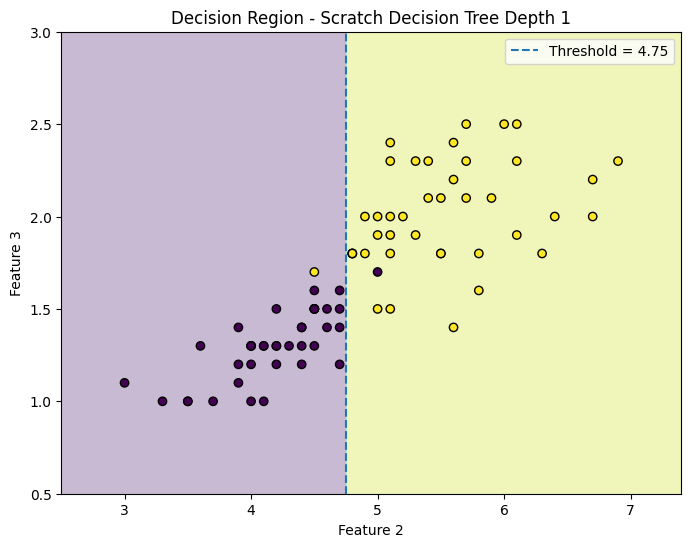

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Use feature 2 for the horizontal axis
feature_x = 2

# Use feature 3 for the vertical axis
feature_y = 3

# Create a 2D grid
x_min = X[:, feature_x].min() - 0.5
x_max = X[:, feature_x].max() + 0.5

y_min = X[:, feature_y].min() - 0.5
y_max = X[:, feature_y].max() + 0.5

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

# Create grid data with the same number of features as the original data
grid = np.zeros((xx.size, X.shape[1]))

# Fill the two displayed features
grid[:, feature_x] = xx.ravel()
grid[:, feature_y] = yy.ravel()

# Fill the other features with their training-set mean
for feature in range(X.shape[1]):
    if feature != feature_x and feature != feature_y:
        grid[:, feature] = X_train[:, feature].mean()

# Predict the class for every grid point
Z = scratch_model.predict(grid)

Z = Z.reshape(xx.shape)

# Plot decision regions
plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

# Plot training samples
plt.scatter(
    X_train[:, feature_x],
    X_train[:, feature_y],
    c=y_train,
    edgecolors="black"
)

# Decision boundary
plt.axvline(
    scratch_model.threshold_,
    linestyle="--",
    label=f"Threshold = {scratch_model.threshold_}"
)

plt.xlabel("Feature 2")
plt.ylabel("Feature 3")
plt.title("Decision Region - Scratch Decision Tree Depth 1")
plt.legend()
plt.show()

### Explanation

A depth-1 decision tree makes only one split from the root node. In our model, the split is based on **Feature 2** with a threshold of **4.75**.

- If `Feature 2 <= 4.75`, the sample is classified as **Class 0**.
- If `Feature 2 > 4.75`, the sample is classified as **Class 1**.

The decision boundary is therefore a **vertical line at Feature 2 = 4.75**, because Feature 2 is represented on the horizontal axis.

The left and right regions of the graph represent the two classes predicted by the decision tree. The observed samples are plotted on top of these regions to show how they are classified.

Since the tree has a depth of 1, it can create only one decision boundary. If the selected feature were on the vertical axis, the boundary would instead be horizontal.

In [ ]:
## Problem 7

In [ ]:
class DecisionTreeNode:

    def __init__(self):
        self.feature_index = None
        self.threshold = None
        self.prediction = None

        self.left = None
        self.right = None


class ScratchDecisionTreeClassifierDepth2:

    def __init__(self, verbose=False):
        self.verbose = verbose
        self.root = None

    def _majority_class(self, y):
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    def _find_best_split(self, X, y):

        best_gain = -1
        best_feature = None
        best_threshold = None

        for feature in range(X.shape[1]):

            values = np.unique(X[:, feature])

            if len(values) < 2:
                continue

            thresholds = (values[:-1] + values[1:]) / 2

            for threshold in thresholds:

                left = X[:, feature] <= threshold
                right = X[:, feature] > threshold

                if np.sum(left) == 0 or np.sum(right) == 0:
                    continue

                y_left = y[left]
                y_right = y[right]

                all_classes = np.unique(y)

                left_classes, left_counts = np.unique(
                    y_left,
                    return_counts=True
                )

                right_classes, right_counts = np.unique(
                    y_right,
                    return_counts=True
                )

                left_dict = dict(zip(left_classes, left_counts))
                right_dict = dict(zip(right_classes, right_counts))

                left_counts_all = [
                    left_dict.get(c, 0)
                    for c in all_classes
                ]

                right_counts_all = [
                    right_dict.get(c, 0)
                    for c in all_classes
                ]

                gain = information_gain(
                    left_counts_all,
                    right_counts_all
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def _build_tree(self, X, y, depth):

        node = DecisionTreeNode()

        # Majority class at this node
        node.prediction = self._majority_class(y)

        # Stop at depth 2
        if depth >= 2:
            return node

        # Find the best split
        feature, threshold, gain = self._find_best_split(X, y)

        # No valid split
        if feature is None:
            return node

        node.feature_index = feature
        node.threshold = threshold

        left = X[:, feature] <= threshold
        right = X[:, feature] > threshold

        # Build the two child nodes
        node.left = self._build_tree(
            X[left],
            y[left],
            depth + 1
        )

        node.right = self._build_tree(
            X[right],
            y[right],
            depth + 1
        )

        return node

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        # Build tree starting from the root
        self.root = self._build_tree(X, y, depth=0)

        return self

    def predict(self, X):

        X = np.asarray(X)

        predictions = []

        for sample in X:

            node = self.root

            while node.left is not None and node.right is not None:

                if sample[node.feature_index] <= node.threshold:
                    node = node.left
                else:
                    node = node.right

            predictions.append(node.prediction)

        return np.array(predictions)

In [ ]:
model_depth2 = ScratchDecisionTreeClassifierDepth2()

model_depth2.fit(X_train, y_train)

y_pred_depth2 = model_depth2.predict(X_test)

print(y_pred_depth2)

[1 1 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 1 0]


In [ ]:
## Problem 8

In [ ]:
class ScratchDecisionTreeClassifierDepthInf:

    def __init__(self, max_depth=None, min_samples_split=2, verbose=False):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.verbose = verbose
        self.root = None

    def _majority_class(self, y):
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    def _find_best_split(self, X, y):

        best_gain = 0.0
        best_feature = None
        best_threshold = None

        all_classes = np.unique(y)

        for feature in range(X.shape[1]):

            values = np.unique(X[:, feature])

            if len(values) < 2:
                continue

            # Thresholds between adjacent unique values
            thresholds = (values[:-1] + values[1:]) / 2

            for threshold in thresholds:

                left = X[:, feature] <= threshold
                right = X[:, feature] > threshold

                # Ignore empty splits
                if np.sum(left) == 0 or np.sum(right) == 0:
                    continue

                y_left = y[left]
                y_right = y[right]

                left_classes, left_counts = np.unique(
                    y_left,
                    return_counts=True
                )

                right_classes, right_counts = np.unique(
                    y_right,
                    return_counts=True
                )

                left_dict = dict(zip(left_classes, left_counts))
                right_dict = dict(zip(right_classes, right_counts))

                left_counts_all = [
                    left_dict.get(c, 0)
                    for c in all_classes
                ]

                right_counts_all = [
                    right_dict.get(c, 0)
                    for c in all_classes
                ]

                gain = information_gain(
                    left_counts_all,
                    right_counts_all
                )

                # Keep only positive-gain splits
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def _build_tree(self, X, y, depth):

        node = DecisionTreeNode()

        # Prediction at this node = majority class
        node.prediction = self._majority_class(y)

        # --------------------------------------------------
        # Stopping condition 1:
        # Maximum depth reached
        # --------------------------------------------------
        if self.max_depth is not None and depth >= self.max_depth:
            return node

        # --------------------------------------------------
        # Stopping condition 2:
        # All labels are identical
        # --------------------------------------------------
        if len(np.unique(y)) == 1:
            return node

        # --------------------------------------------------
        # Stopping condition 3:
        # Too few samples to split
        # --------------------------------------------------
        if len(y) < self.min_samples_split:
            return node

        # Find the best valid split
        feature, threshold, gain = self._find_best_split(X, y)

        # --------------------------------------------------
        # Stopping condition 4:
        # No valid split with positive information gain
        # --------------------------------------------------
        if feature is None or gain <= 0:
            return node

        # Save split information
        node.feature_index = feature
        node.threshold = threshold

        # Split data
        left = X[:, feature] <= threshold
        right = X[:, feature] > threshold

        # Recursively build child nodes
        node.left = self._build_tree(
            X[left],
            y[left],
            depth + 1
        )

        node.right = self._build_tree(
            X[right],
            y[right],
            depth + 1
        )

        return node

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        self.root = self._build_tree(
            X,
            y,
            depth=0
        )

        return self

    def predict(self, X):

        X = np.asarray(X)

        predictions = []

        for sample in X:

            node = self.root

            # Traverse the learned tree
            while node.left is not None and node.right is not None:

                if sample[node.feature_index] <= node.threshold:
                    node = node.left
                else:
                    node = node.right

            # Leaf prediction
            predictions.append(node.prediction)

        return np.array(predictions)

In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X_all, y_all = load_iris(return_X_y=True)

mask = y_all != 0
X = X_all[mask]
y = y_all[mask] - 1

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80, 4)
X_test: (20, 4)
y_train: (80,)
y_test: (20,)


In [ ]:
import numpy as np

In [ ]:
import numpy as np


class DecisionTreeNode:

    def __init__(self):
        self.feature_index = None
        self.threshold = None
        self.prediction = None

        self.left = None
        self.right = None

In [ ]:
import numpy as np


class DecisionTreeNode:

    def __init__(self):
        self.feature_index = None
        self.threshold = None
        self.prediction = None
        self.left = None
        self.right = None


class ScratchDecisionTree:

    def __init__(self, max_depth=None, min_samples_split=2, verbose=False):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.verbose = verbose
        self.root = None

    def _majority_class(self, y):
        classes, counts = np.unique(y, return_counts=True)
        return classes[np.argmax(counts)]

    def _find_best_split(self, X, y):

        best_gain = 0.0
        best_feature = None
        best_threshold = None

        all_classes = np.unique(y)

        for feature in range(X.shape[1]):

            values = np.unique(X[:, feature])

            if len(values) < 2:
                continue

            thresholds = (values[:-1] + values[1:]) / 2

            for threshold in thresholds:

                left = X[:, feature] <= threshold
                right = X[:, feature] > threshold

                if np.sum(left) == 0 or np.sum(right) == 0:
                    continue

                y_left = y[left]
                y_right = y[right]

                left_classes, left_counts = np.unique(
                    y_left, return_counts=True
                )

                right_classes, right_counts = np.unique(
                    y_right, return_counts=True
                )

                left_dict = dict(zip(left_classes, left_counts))
                right_dict = dict(zip(right_classes, right_counts))

                left_counts_all = [
                    left_dict.get(c, 0) for c in all_classes
                ]

                right_counts_all = [
                    right_dict.get(c, 0) for c in all_classes
                ]

                gain = information_gain(
                    left_counts_all,
                    right_counts_all
                )

                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        return best_feature, best_threshold, best_gain

    def _build_tree(self, X, y, depth):

        node = DecisionTreeNode()

        node.prediction = self._majority_class(y)

        # Maximum depth reached
        if self.max_depth is not None and depth >= self.max_depth:
            return node

        # All labels are identical
        if len(np.unique(y)) == 1:
            return node

        # Too few samples
        if len(y) < self.min_samples_split:
            return node

        feature, threshold, gain = self._find_best_split(X, y)

        # No valid positive-gain split
        if feature is None or gain <= 0:
            return node

        node.feature_index = feature
        node.threshold = threshold

        left = X[:, feature] <= threshold
        right = X[:, feature] > threshold

        node.left = self._build_tree(
            X[left],
            y[left],
            depth + 1
        )

        node.right = self._build_tree(
            X[right],
            y[right],
            depth + 1
        )

        return node

    def fit(self, X, y):

        X = np.asarray(X)
        y = np.asarray(y)

        self.root = self._build_tree(
            X, y, depth=0
        )

        return self

    def predict(self, X):

        X = np.asarray(X)

        predictions = []

        for sample in X:

            node = self.root

            while node.left is not None and node.right is not None:

                if sample[node.feature_index] <= node.threshold:
                    node = node.left
                else:
                    node = node.right

            predictions.append(node.prediction)

        return np.array(predictions)

In [ ]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

X_all, y_all = load_iris(return_X_y=True)

mask = y_all != 0

X = X_all[mask]
y = y_all[mask] - 1

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=0
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (80, 4)
X_test: (20, 4)
y_train: (80,)
y_test: (20,)


In [ ]:
def information_gain(left_counts, right_counts):

    n_left = sum(left_counts)
    n_right = sum(right_counts)
    n_parent = n_left + n_right

    # Invalid split
    if n_left == 0 or n_right == 0:
        return 0.0

    parent_counts = [
        left_counts[i] + right_counts[i]
        for i in range(len(left_counts))
    ]

    gini_parent = gini_impurity(parent_counts)
    gini_left = gini_impurity(left_counts)
    gini_right = gini_impurity(right_counts)

    weighted_impurity = (
        (n_left / n_parent) * gini_left
        + (n_right / n_parent) * gini_right
    )

    return gini_parent - weighted_impurity

In [ ]:
def gini_impurity(class_counts):

    total = sum(class_counts)

    if total == 0:
        return 0.0

    impurity = 1.0

    for count in class_counts:
        probability = count / total
        impurity -= probability ** 2

    return impurity

In [ ]:
model_depth_inf = ScratchDecisionTree(
    max_depth=None
)

model_depth_inf.fit(X_train, y_train)

y_pred_depth_inf = model_depth_inf.predict(X_test)

print("Predictions:")
print(y_pred_depth_inf)

print("Shape:")
print(y_pred_depth_inf.shape)

Predictions:
[0 1 0 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 1 0]
Shape:
(20,)
